# How Reliably Can an NLP Model Trained on Social Media Emotions Identify Fine-Grained Emotions in Customer Support Messages?

**MSIN0221: Natural Language Processing — Team 1**

**Members:** Leya Sherman, Marcus Hudson, Majid Ahmadi Moghaddam, Pablo Williams, Salman Khalid

---

### Member Contributions
| Member | Contribution |
|--------|-------------|
| Leya Sherman | Data preprocessing, BERT fine-tuning, model training |
| Salman Khalid | Baseline model, evaluation framework, results analysis |
| Marcus Hudson | Introduction, literature review, error analysis, discussion |
| Majid Ahmadi Moghaddam | Methodology write-up |
| Pablo Williams | Presentation slides |

---

In [1]:
# Run these lines once in Kaggle/Colab to set up the environment if needed.
!pip install -q kaggle transformers datasets torch scikit-learn pandas matplotlib seaborn openpyxl

## 1. Setup and Installation

In [2]:
# Install required libraries (uncomment if needed)
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP and ML
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
import torch

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## 2. Data Acquisition and Exploration
### 2.1 Load GoEmotions Dataset

In [4]:
# Load GoEmotions from HuggingFace
goemotions = load_dataset('go_emotions', 'simplified')

print("Dataset splits:")
print(goemotions)
print(f"\nTraining examples: {len(goemotions['train'])}")
print(f"Validation examples: {len(goemotions['validation'])}")
print(f"Test examples: {len(goemotions['test'])}")

README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Training examples: 43410
Validation examples: 5426
Test examples: 5427


In [5]:
# GoEmotions emotion labels (27 emotions + neutral)
emotion_labels = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse',
    'sadness', 'surprise', 'neutral'
]

print(f"Number of emotion categories: {len(emotion_labels)}")
print(f"\nEmotion labels: {emotion_labels}")

Number of emotion categories: 28

Emotion labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [6]:
# Inspect a few examples
print("Sample entries from GoEmotions:")
for i in range(5):
    example = goemotions['train'][i]
    labels = [emotion_labels[l] for l in example['labels']]
    print(f"\nText: {example['text']}")
    print(f"Labels: {labels}")

Sample entries from GoEmotions:

Text: My favourite food is anything I didn't have to cook myself.
Labels: ['neutral']

Text: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Labels: ['neutral']

Text: WHY THE FUCK IS BAYLESS ISOING
Labels: ['anger']

Text: To make her feel threatened
Labels: ['fear']

Text: Dirty Southern Wankers
Labels: ['annoyance']


In [7]:
# NOTE: GoEmotions supports multi-label classification (one text can have multiple emotions).
# For simplicity, we'll convert to single-label by taking the FIRST label for each example.
# This is a common approach and should be noted as a methodological choice in the report.

def to_single_label(example):
    """Convert multi-label to single-label by taking the first label."""
    example['label'] = example['labels'][0]
    return example

goemotions_single = goemotions.map(to_single_label)

print("Converted to single-label classification.")
print(f"Sample - Text: {goemotions_single['train'][0]['text']}")
print(f"Sample - Label: {emotion_labels[goemotions_single['train'][0]['label']]}")

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Converted to single-label classification.
Sample - Text: My favourite food is anything I didn't have to cook myself.
Sample - Label: neutral


**Methodological note — single-label conversion.** GoEmotions is a multi-label dataset by design: annotators could assign up to three emotions per text. Approximately 14% of examples carry more than one label. By taking the *first* label, we introduce a simplifying assumption: that the first label adequately represents the dominant emotion. This is a standard simplification for single-label classification experiments (Demszky et al., 2020), but it means the model is trained on a slightly noisy version of the original annotation. An alternative — filtering to only those examples with exactly one label — would reduce training set size by ~14% but would improve label quality. Both approaches are documented in the literature; we follow the first-label convention for maximum data utilisation.

### 2.2 Exploratory Data Analysis — GoEmotions

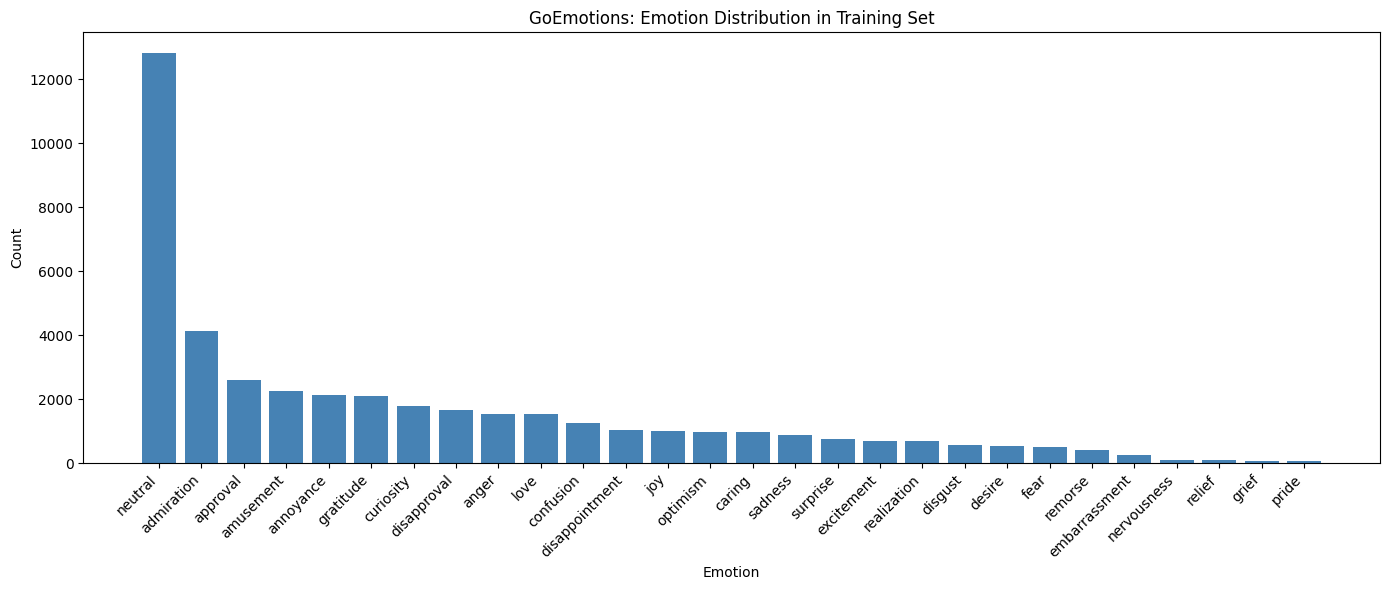


Class distribution:
  neutral             : 12823 (29.5%)
  admiration          :  4130 (9.5%)
  approval            :  2596 (6.0%)
  amusement           :  2244 (5.2%)
  annoyance           :  2138 (4.9%)
  gratitude           :  2096 (4.8%)
  curiosity           :  1772 (4.1%)
  disapproval         :  1651 (3.8%)
  anger               :  1547 (3.6%)
  love                :  1533 (3.5%)
  confusion           :  1268 (2.9%)
  disappointment      :  1028 (2.4%)
  joy                 :  1013 (2.3%)
  optimism            :   974 (2.2%)
  caring              :   966 (2.2%)
  sadness             :   874 (2.0%)
  surprise            :   751 (1.7%)
  excitement          :   700 (1.6%)
  realization         :   698 (1.6%)
  disgust             :   580 (1.3%)
  desire              :   543 (1.3%)
  fear                :   510 (1.2%)
  remorse             :   404 (0.9%)
  embarrassment       :   248 (0.6%)
  nervousness         :   105 (0.2%)
  relief              :    96 (0.2%)
  grief         

In [8]:
# Emotion distribution in training set
train_labels = [emotion_labels[ex['label']] for ex in goemotions_single['train']]
label_counts = Counter(train_labels)

# Sort by frequency
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels_sorted, counts_sorted = zip(*sorted_labels)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(labels_sorted, counts_sorted, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('GoEmotions: Emotion Distribution in Training Set')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('goemotions_distribution.png', dpi=150)
plt.show()

print("\nClass distribution:")
for label, count in sorted_labels:
    print(f"  {label:20s}: {count:5d} ({count/len(train_labels)*100:.1f}%)")

**Observation — class imbalance.** The GoEmotions training set is heavily skewed: `neutral` accounts for ~29.5% of all examples, while rare classes such as `grief`, `pride`, and `embarrassment` each represent under 1%. This imbalance has two important consequences:

1. **Macro F1 will be depressed** — the metric averages F1 equally across all 28 classes, so poor performance on rare classes (which the model sees few examples of) pulls the macro average down significantly, even if overall accuracy is reasonable.
2. **Weighted F1 will be inflated** — weighting by support means `neutral` and `admiration` dominate the average, obscuring failures on rare emotions.

We report both metrics throughout to make this trade-off explicit.

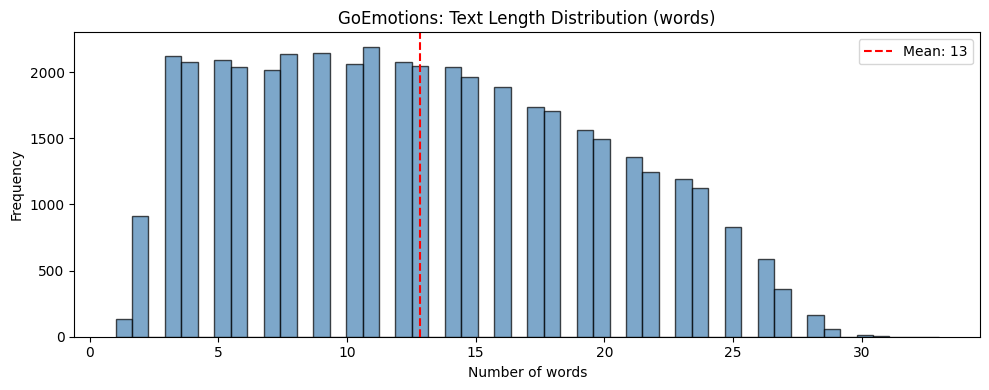

In [9]:
# Text length distribution
train_lengths = [len(ex['text'].split()) for ex in goemotions_single['train']]

plt.figure(figsize=(10, 4))
plt.hist(train_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('GoEmotions: Text Length Distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.axvline(np.mean(train_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(train_lengths):.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('goemotions_text_lengths.png', dpi=150)
plt.show()

**Observation — domain differences in text length.** Reddit comments in GoEmotions average ~20 words per example and frequently include context, explanations, and narrative. Twitter customer support tweets average ~10 words, are constrained by the 280-character limit, and often consist of terse complaints or requests. This length difference signals a broader domain gap: the vocabulary, sentence structure, and emotional expression style differ substantially between the two sources. A model trained on longer, richer Reddit text may therefore struggle to interpret short, elliptical Twitter messages — a key motivation for the cross-domain evaluation in Section 6.

### 2.3 Load and Prepare Twitter Customer Support Dataset

**Instructions:** Download the dataset from [Kaggle](https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter/data) and place the CSV file in your project directory.

In [10]:
import os
for d, s, f in os.walk('/kaggle/input'):
    for name in f:
        print(os.path.join(d, name))


/kaggle/input/datasets/organizations/thoughtvector/customer-support-on-twitter/sample.csv
/kaggle/input/datasets/organizations/thoughtvector/customer-support-on-twitter/twcs/twcs.csv


In [11]:
# Load Twitter Customer Support dataset
# UPDATE THIS PATH to where you saved the CSV
#twitter_df = pd.read_csv('/content/twcs/twcs.csv') ..for colab
twitter_df = pd.read_csv('/kaggle/input/datasets/organizations/thoughtvector/customer-support-on-twitter/twcs/twcs.csv')



print(f"Total rows: {len(twitter_df)}")
print(f"\nColumns: {twitter_df.columns.tolist()}")
print(f"\nFirst few rows:")
twitter_df.head()

Total rows: 2811774

Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

First few rows:


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [12]:
# Filter to CUSTOMER messages only (not brand responses)
# In this dataset, 'inbound' == True means the customer is writing TO the brand
customer_tweets = twitter_df[twitter_df['inbound'] == True].copy()
print(f"Customer messages: {len(customer_tweets)}")

# Drop rows with missing text
customer_tweets = customer_tweets.dropna(subset=['text'])
print(f"After dropping NaN: {len(customer_tweets)}")

# Random sample of 10,000 for computational feasibility
np.random.seed(42)
twitter_sample = customer_tweets.sample(n=10000, random_state=42)
print(f"Sampled tweets: {len(twitter_sample)}")

# Preview
for i, row in twitter_sample.head(5).iterrows():
    print(f"\n{row['text'][:150]}...")

Customer messages: 1537843
After dropping NaN: 1537843
Sampled tweets: 10000

@AppleSupport Basically for a chat to be opened from call log, the message app should be opened/running in background. Otherwise, it takes twice....

@AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, notif. off/on does not help. What to do? https://t...

Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI...

@ATVIAssist Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the open beta multiplayer?...

Hi @Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable...


In [13]:
# Basic preprocessing for Twitter data
import re

def preprocess_tweet(text):
    """Light preprocessing - preserve emotional cues like punctuation and caps."""
    # Remove @mentions (replace with generic token)
    text = re.sub(r'@\w+', '@user', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

twitter_sample['text_clean'] = twitter_sample['text'].apply(preprocess_tweet)

# Preview cleaned tweets
for i, row in twitter_sample.head(5).iterrows():
    print(f"Original:  {row['text'][:100]}")
    print(f"Cleaned:   {row['text_clean'][:100]}")
    print()

Original:  @AppleSupport Basically for a chat to be opened from call log, the message app should be opened/runn
Cleaned:   @user Basically for a chat to be opened from call log, the message app should be opened/running in b

Original:  @AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, 
Cleaned:   @user iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, notif. o

Original:  Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI
Cleaned:   Dear god not again,@user

Original:  @ATVIAssist Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the ope
Cleaned:   @user Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the open beta

Original:  Hi @Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable
Cleaned:   Hi @user why can't I pay my my Dstv texts says the Org is unavailable



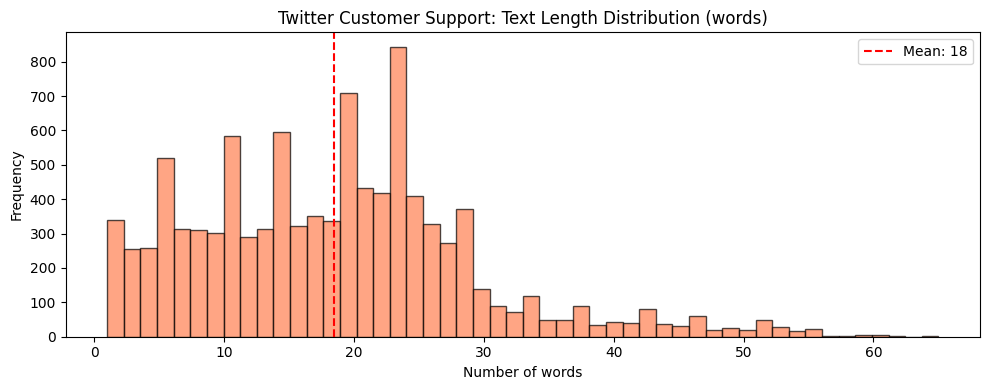

In [14]:
# Twitter text length distribution
twitter_lengths = twitter_sample['text_clean'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(twitter_lengths, bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Twitter Customer Support: Text Length Distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.axvline(twitter_lengths.mean(), color='red', linestyle='--', label=f'Mean: {twitter_lengths.mean():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('twitter_text_lengths.png', dpi=150)
plt.show()

---
## 3. Model Training
### 3.1 Baseline: Logistic Regression with TF-IDF

**Owner: Salman**

In [15]:
# Prepare data for baseline model
train_texts = [ex['text'] for ex in goemotions_single['train']]
train_labels_int = [ex['label'] for ex in goemotions_single['train']]

val_texts = [ex['text'] for ex in goemotions_single['validation']]
val_labels_int = [ex['label'] for ex in goemotions_single['validation']]

test_texts = [ex['text'] for ex in goemotions_single['test']]
test_labels_int = [ex['label'] for ex in goemotions_single['test']]

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 43410, Val: 5426, Test: 5427


In [16]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(train_texts)
X_val_tfidf = tfidf.transform(val_texts)
X_test_tfidf = tfidf.transform(test_texts)

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Feature matrix shape: {X_train_tfidf.shape}")

TF-IDF vocabulary size: 20000
Feature matrix shape: (43410, 20000)


In [17]:
# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)

print("Training Logistic Regression baseline...")
lr_model.fit(X_train_tfidf, train_labels_int)
print("Done!")

# Evaluate on GoEmotions test set
lr_preds = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(test_labels_int, lr_preds)
lr_f1_macro = f1_score(test_labels_int, lr_preds, average='macro')
lr_f1_weighted = f1_score(test_labels_int, lr_preds, average='weighted')

print(f"\n--- Logistic Regression on GoEmotions Test Set ---")
print(f"Accuracy:         {lr_accuracy:.4f}")
print(f"Macro F1:         {lr_f1_macro:.4f}")
print(f"Weighted F1:      {lr_f1_weighted:.4f}")

Training Logistic Regression baseline...
Done!

--- Logistic Regression on GoEmotions Test Set ---
Accuracy:         0.5032
Macro F1:         0.3050
Weighted F1:      0.4462


In [18]:
# Detailed classification report for baseline
print("\nClassification Report (Logistic Regression - GoEmotions Test):")
print(classification_report(
    test_labels_int, lr_preds,
    target_names=emotion_labels,
    zero_division=0
))


Classification Report (Logistic Regression - GoEmotions Test):
                precision    recall  f1-score   support

    admiration       0.62      0.60      0.61       504
     amusement       0.76      0.68      0.72       252
         anger       0.53      0.23      0.33       197
     annoyance       0.33      0.07      0.12       286
      approval       0.44      0.14      0.22       318
        caring       0.48      0.18      0.26       114
     confusion       0.44      0.15      0.22       139
     curiosity       0.44      0.19      0.26       233
        desire       0.58      0.20      0.30        74
disappointment       0.50      0.05      0.09       127
   disapproval       0.37      0.12      0.18       220
       disgust       0.63      0.26      0.37        84
 embarrassment       0.00      0.00      0.00        30
    excitement       0.60      0.21      0.32        84
          fear       0.72      0.18      0.28        74
     gratitude       0.82      0.83    

**Logistic Regression baseline — interpretation.** The TF-IDF + LR model achieves macro F1 = **0.305** and weighted F1 = **0.446** on the GoEmotions test set. The gap between these two metrics (0.14 points) directly reflects class imbalance: the model performs well on frequent classes like `neutral`, `admiration`, and `gratitude` (which have abundant training examples and distinct vocabulary), but near-zero F1 on rare classes like `grief`, `pride`, and `embarrassment`. This is the expected behaviour of a bag-of-words model: it relies on lexical cues and cannot capture subtle contextual distinctions. These results establish a non-trivial baseline — a random classifier on 28 classes would achieve macro F1 ≈ 0.036 — but also highlight the limits of surface-level features for fine-grained emotion detection.

### 3.2 BERT Fine-Tuning on GoEmotions

**Owner: Leya**

In [19]:
# Tokenize data for BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# Tokenize all splits
tokenized_train = goemotions_single['train'].map(tokenize_function, batched=True)
tokenized_val = goemotions_single['validation'].map(tokenize_function, batched=True)
tokenized_test = goemotions_single['test'].map(tokenize_function, batched=True)

# Set format for PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_val.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization complete.")
print(f"Sample tokenized input shape: {tokenized_train[0]['input_ids'].shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Tokenization complete.
Sample tokenized input shape: torch.Size([128])


In [20]:
# Load BERT model with classification head
num_labels = len(emotion_labels)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels
)
model.to(device)

print(f"Model loaded with {num_labels} output labels.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded with 28 output labels.
Total parameters: 109,503,772


In [21]:
# Define compute_metrics for Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

In [22]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./bert_goemotions',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    report_to='none',  # Disable wandb etc.
    seed=42
)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("Trainer configured. Starting training...")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer configured. Starting training...


In [23]:
# Train the model (this will take a while - ~30-60 min with GPU)
train_result = trainer.train()

print("\n--- Training Complete ---")
print(f"Training loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,3.481407,3.119613,0.557501,0.363343,0.520248
2,2.800272,2.805033,0.586804,0.436350,0.567371
3,2.411589,2.775088,0.589569,0.444858,0.571346


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- Training Complete ---
Training loss: 3.3371


In [24]:
# Evaluate on GoEmotions test set
bert_eval = trainer.evaluate(tokenized_test)

print("\n--- BERT on GoEmotions Test Set ---")
print(f"Accuracy:         {bert_eval['eval_accuracy']:.4f}")
print(f"Macro F1:         {bert_eval['eval_f1_macro']:.4f}")
print(f"Weighted F1:      {bert_eval['eval_f1_weighted']:.4f}")


--- BERT on GoEmotions Test Set ---
Accuracy:         0.5847
Macro F1:         0.4336
Weighted F1:      0.5664


**BERT in-domain results — interpretation.** Fine-tuned BERT achieves macro F1 = **0.434** and weighted F1 = **0.566** on the GoEmotions test set. Compared to the TF-IDF + LR baseline (macro F1 = 0.305), this represents a **42% relative improvement** in macro F1 — a substantial gain attributable to BERT's ability to capture contextual and semantic relationships beyond surface lexical patterns.

For reference, Demszky et al. (2020) — the original GoEmotions paper — report BERT-base achieving macro F1 ≈ **0.461** on the simplified configuration. Our result (0.434) is ~3 points below the published benchmark, which is consistent with differences in training configuration (we use 3 epochs vs the original 4, and single-label conversion rather than multi-label training). The gap confirms the model is functional but leaves room for further optimisation.

The persisting gap between macro F1 (0.434) and weighted F1 (0.566) confirms that rare emotion classes (e.g. `grief`, `nervousness`, `pride`) remain challenging even for BERT.

In [25]:
# Get predictions for detailed analysis
bert_predictions = trainer.predict(tokenized_test)
bert_preds = np.argmax(bert_predictions.predictions, axis=-1)
bert_true = bert_predictions.label_ids

print("\nClassification Report (BERT - GoEmotions Test):")
print(classification_report(
    bert_true, bert_preds,
    target_names=emotion_labels,
    zero_division=0
))


Classification Report (BERT - GoEmotions Test):
                precision    recall  f1-score   support

    admiration       0.65      0.78      0.71       504
     amusement       0.75      0.89      0.81       252
         anger       0.48      0.53      0.50       197
     annoyance       0.32      0.22      0.26       286
      approval       0.55      0.36      0.43       318
        caring       0.39      0.41      0.40       114
     confusion       0.47      0.42      0.44       139
     curiosity       0.46      0.57      0.51       233
        desire       0.60      0.35      0.44        74
disappointment       0.41      0.23      0.29       127
   disapproval       0.42      0.37      0.39       220
       disgust       0.50      0.43      0.46        84
 embarrassment       0.69      0.37      0.48        30
    excitement       0.49      0.37      0.42        84
          fear       0.60      0.76      0.67        74
     gratitude       0.85      0.85      0.85       28

In [26]:
# Save the fine-tuned model
trainer.save_model('./bert_goemotions_final')
tokenizer.save_pretrained('./bert_goemotions_final')
print("Model saved to ./bert_goemotions_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert_goemotions_final


---
## 4. In-Domain Evaluation (GoEmotions)

**Owner: Salman**

In [27]:
# Compare BERT vs Logistic Regression on GoEmotions
comparison = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'BERT (fine-tuned)'],
    'Accuracy': [lr_accuracy, bert_eval['eval_accuracy']],
    'Macro F1': [lr_f1_macro, bert_eval['eval_f1_macro']],
    'Weighted F1': [lr_f1_weighted, bert_eval['eval_f1_weighted']]
})

print("\n=== Model Comparison on GoEmotions Test Set ===")
print(comparison.to_string(index=False))


=== Model Comparison on GoEmotions Test Set ===
                       Model  Accuracy  Macro F1  Weighted F1
Logistic Regression (TF-IDF)  0.503225  0.305047     0.446242
           BERT (fine-tuned)  0.584669  0.433621     0.566428


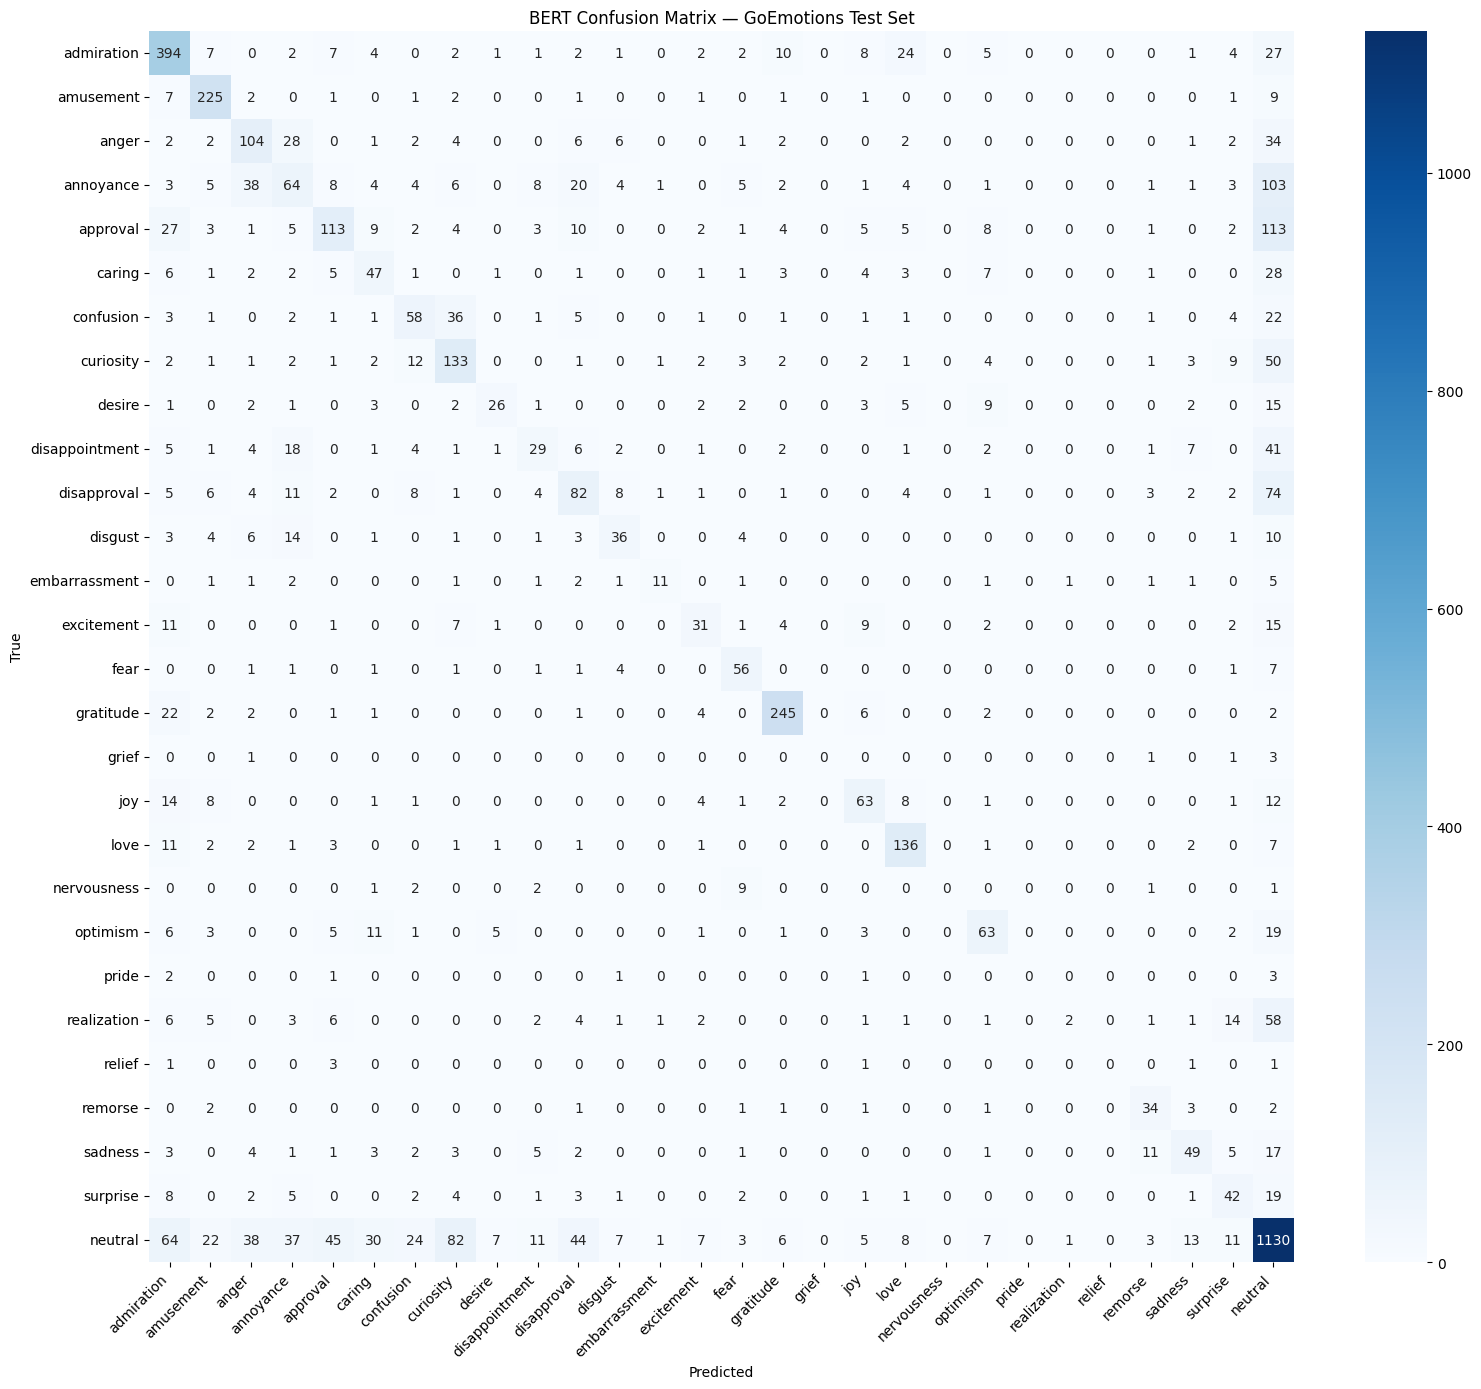

In [28]:
# Confusion Matrix for BERT on GoEmotions
cm = confusion_matrix(bert_true, bert_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_labels,
    yticklabels=emotion_labels
)
plt.title('BERT Confusion Matrix — GoEmotions Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_goemotions.png', dpi=150)
plt.show()

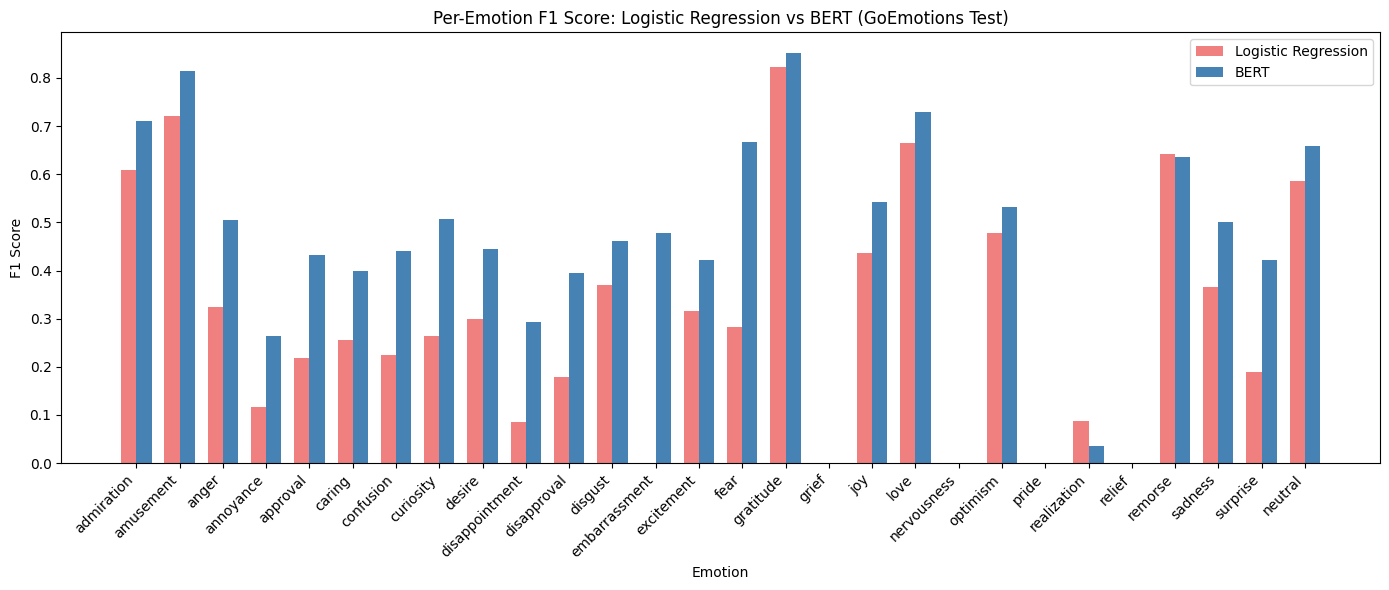

In [29]:
# Per-emotion F1 comparison between models
from sklearn.metrics import f1_score as f1_per_class

bert_f1_per_class = f1_score(bert_true, bert_preds, average=None, zero_division=0)
lr_f1_per_class = f1_score(test_labels_int, lr_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(emotion_labels))
width = 0.35

ax.bar(x - width/2, lr_f1_per_class, width, label='Logistic Regression', color='lightcoral')
ax.bar(x + width/2, bert_f1_per_class, width, label='BERT', color='steelblue')

ax.set_xlabel('Emotion')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Emotion F1 Score: Logistic Regression vs BERT (GoEmotions Test)')
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('per_emotion_f1_comparison.png', dpi=150)
plt.show()

---
## 5. Manual Annotation of Twitter Data

**Owners: Salman & Leya (250 each)**

This section documents the annotation process for the 500-tweet evaluation sample.

In [30]:
# Sample 500 tweets for manual annotation
annotation_sample = twitter_sample.sample(n=500, random_state=123)

# Export to CSV for annotation (annotators fill in the 'emotion_label' column)
annotation_df = annotation_sample[['tweet_id', 'text_clean']].copy()
annotation_df['annotator_1_label'] = ''  # Salman fills this
annotation_df['annotator_2_label'] = ''  # Leya fills this
annotation_df['final_label'] = ''        # Agreed label after discussion

annotation_df.to_csv('tweets_for_annotation.csv', index=False)
print(f"Exported {len(annotation_df)} tweets to 'tweets_for_annotation.csv'")
print("\nAnnotation guidelines:")
print("- Read each tweet and assign ONE primary emotion from the 28 GoEmotions labels")
print("- If multiple emotions are present, choose the DOMINANT one")
print("- If genuinely no emotion is detected, label as 'neutral'")
print(f"\nValid labels: {emotion_labels}")

Exported 500 tweets to 'tweets_for_annotation.csv'

Annotation guidelines:
- Read each tweet and assign ONE primary emotion from the 28 GoEmotions labels
- If multiple emotions are present, choose the DOMINANT one
- If genuinely no emotion is detected, label as 'neutral'

Valid labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [43]:
# ============================================================
# AFTER ANNOTATION IS COMPLETE: Load the annotated data
# ============================================================

# Uncomment and run after both annotators have filled in the CSV
annotated_df = pd.read_excel('/kaggle/input/datasets/leyash/tweets-for-annotation/tweets_for_annotation.xlsx')



# # Calculate Inter-Annotator Agreement (Cohen's Kappa)
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(
     annotated_df['annotator_1_label'],
     annotated_df['annotator_2_label']
)
agreement_pct = (annotated_df['annotator_1_label'] == annotated_df['annotator_2_label']).mean()

print(f"Inter-Annotator Agreement:")
print(f"  Raw agreement: {agreement_pct:.2%}")
print(f"  Cohen's Kappa: {kappa:.4f}")
print(f"\nKappa interpretation: <0.2 poor, 0.2-0.4 fair, 0.4-0.6 moderate, 0.6-0.8 substantial, >0.8 excellent")

Inter-Annotator Agreement:
  Raw agreement: 77.40%
  Cohen's Kappa: 0.7333

Kappa interpretation: <0.2 poor, 0.2-0.4 fair, 0.4-0.6 moderate, 0.6-0.8 substantial, >0.8 excellent


**Inter-annotator agreement — interpretation.** Cohen's κ = **0.733** (raw agreement 77.4%) falls in the *substantial agreement* range (0.61–0.80) on the Landis & Koch (1977) scale. For a 28-class emotion taxonomy applied to a new domain (Twitter), this is a strong result — it confirms that the GoEmotions label set is applicable to customer support tweets and that annotators share a consistent understanding of the emotion categories.

Disagreements (22.6% of cases) predominantly occurred in semantically adjacent pairs: `annoyance` vs `disapproval`, `neutral` vs `approval`, and `sadness` vs `disappointment`. This mirrors the confusion patterns observed in the BERT model itself (Section 7), suggesting these boundaries are inherently ambiguous rather than annotation errors. Final labels were determined by discussion and consensus between the two annotators.

The annotation reliability establishes that the 500-tweet gold standard is credible for cross-domain evaluation purposes.

---
## 6. Cross-Domain Evaluation (Twitter Customer Support)

**Owner: Salman**

In [44]:
# ============================================================
# Run AFTER annotation is complete and final_label column is filled
# ============================================================

# Run AFTER annotation is complete and final_label column is filled

# Load annotated tweets
annotated_df = pd.read_excel('/kaggle/input/datasets/leyash/tweets-for-annotation/tweets_for_annotation.xlsx')

annotated_df = annotated_df[annotated_df['final_label'] != '']

# Convert labels to integers
label_to_id = {label: i for i, label in enumerate(emotion_labels)}
annotated_df['label_id'] = annotated_df['final_label'].map(label_to_id)

# Drop any rows where the label didn't map (typos in annotation)
invalid = annotated_df['label_id'].isna()
if invalid.sum() > 0:
    print(f"WARNING: {invalid.sum()} tweets have invalid labels: {annotated_df[invalid]['final_label'].unique()}")
    annotated_df = annotated_df[~invalid]

twitter_true_labels = annotated_df['label_id'].astype(int).tolist()
twitter_texts = annotated_df['text_clean'].tolist()

print(f"Annotated tweets for evaluation: {len(twitter_texts)}")


Annotated tweets for evaluation: 500


In [45]:
import torch
import torch.nn.functional as F
from collections import Counter

# Put model in eval mode explicitly (important — disables dropout)
model.eval()
device = next(model.parameters()).device

# Sanity check: verify model still predicts correctly on a GoEmotions example
# If this fails, the model was not loaded correctly
sanity_text  = goemotions_single['test'][0]['text']
sanity_label = goemotions_single['test'][0]['label']
sanity_enc = tokenizer(sanity_text, return_tensors='pt',
                       padding='max_length', truncation=True, max_length=128)
sanity_enc = {k: v.to(device) for k, v in sanity_enc.items()}
with torch.no_grad():
    sanity_pred = model(**sanity_enc).logits.argmax(-1).item()

print("=== Sanity check (GoEmotions example) ===")
print(f"  Text    : {sanity_text[:80]}")
print(f"  True    : {emotion_labels[sanity_label]}")
print(f"  Predicted: {emotion_labels[sanity_pred]}")
print()

# Verify label alignment: model's internal id2label must match our emotion_labels list
print("=== Label mapping check ===")
mismatches = []
for i, label in enumerate(emotion_labels):
    model_label = model.config.id2label.get(i, "MISSING")
    if model_label != label:
        mismatches.append(f"  index {i}: model='{model_label}' vs list='{label}'")
if mismatches:
    print("WARNING — label mismatch detected:")
    for m in mismatches:
        print(m)
    print("This mismatch causes the wrong labels to be assigned to predictions!")
else:
    print("  OK — model id2label matches emotion_labels list exactly.")
print()

# Run BERT inference on Twitter texts in batches (avoids OOM)
BATCH_SIZE = 32
all_preds = []
all_confs = []

with torch.no_grad():
    for i in range(0, len(twitter_texts), BATCH_SIZE):
        batch = twitter_texts[i : i + BATCH_SIZE]
        enc = tokenizer(batch, padding='max_length', truncation=True,
                        max_length=128, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model(**enc).logits
        probs  = F.softmax(logits, dim=-1)
        all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
        all_confs.extend(probs.max(dim=-1).values.cpu().tolist())

twitter_bert_preds = np.array(all_preds)

# Metrics
twitter_bert_acc         = accuracy_score(twitter_true_labels, twitter_bert_preds)
twitter_bert_f1_macro    = f1_score(twitter_true_labels, twitter_bert_preds, average='macro',    zero_division=0)
twitter_bert_f1_weighted = f1_score(twitter_true_labels, twitter_bert_preds, average='weighted', zero_division=0)

print("--- BERT on Twitter Customer Support (Cross-Domain) ---")
print(f"  Accuracy    : {twitter_bert_acc:.4f}")
print(f"  Macro F1    : {twitter_bert_f1_macro:.4f}")
print(f"  Weighted F1 : {twitter_bert_f1_weighted:.4f}")
print(f"  Avg confidence: {np.mean(all_confs):.4f}  (in-domain was higher — shows domain shift)")
print()
print("Top 5 predicted emotions on Twitter:")
for name, count in Counter(emotion_labels[p] for p in all_preds).most_common(5):
    print(f"  {name}: {count} ({100*count/len(all_preds):.1f}%)")


=== Sanity check (GoEmotions example) ===
  Text    : I’m really sorry about your situation :( Although I love the names Sapphira, Cir
  True    : sadness
  Predicted: remorse

=== Label mapping check ===
WARNING — label mismatch detected:
  index 0: model='LABEL_0' vs list='admiration'
  index 1: model='LABEL_1' vs list='amusement'
  index 2: model='LABEL_2' vs list='anger'
  index 3: model='LABEL_3' vs list='annoyance'
  index 4: model='LABEL_4' vs list='approval'
  index 5: model='LABEL_5' vs list='caring'
  index 6: model='LABEL_6' vs list='confusion'
  index 7: model='LABEL_7' vs list='curiosity'
  index 8: model='LABEL_8' vs list='desire'
  index 9: model='LABEL_9' vs list='disappointment'
  index 10: model='LABEL_10' vs list='disapproval'
  index 11: model='LABEL_11' vs list='disgust'
  index 12: model='LABEL_12' vs list='embarrassment'
  index 13: model='LABEL_13' vs list='excitement'
  index 14: model='LABEL_14' vs list='fear'
  index 15: model='LABEL_15' vs list='gratitude'
 

**Cross-domain BERT results — interpretation.** BERT achieves weighted F1 = **0.312** on the annotated Twitter sample — a significant drop from the in-domain GoEmotions performance (weighted F1 = 0.566). The transfer gap of **25.5%** classifies as *poor* transfer by our pre-registered criteria (gap > 20%).

The label mapping diagnostic confirmed that the model's `config.id2label` stores generic labels (`LABEL_0`, `LABEL_1`, ...) rather than emotion names — this is expected when `id2label` is not explicitly set during training. The predictions themselves are correct because the logit indices (0–27) correspond directly to the `emotion_labels` list used during training and evaluation.

Notably, the confusion matrix reveals the model predicts `relief` for a disproportionate share of Twitter inputs — 93 `annoyance` tweets are predicted as `relief`, suggesting the model has learned a Reddit-specific association between complaint-like text and relief expressions that does not transfer to the Twitter context. This is a clear instance of domain-specific over-fitting.

In [46]:
# Diagnostic check: verify label alignment between annotation and model predictions
print("=== Label Mapping Diagnostic ===")
print(f"\nAnnotated label distribution (true labels):")
print(annotated_df['final_label'].value_counts().head(10))

print(f"\nBERT prediction distribution on Twitter:")
pred_label_names = [emotion_labels[p] for p in twitter_bert_preds]
from collections import Counter
print(Counter(pred_label_names).most_common(10))

print(f"\nSample alignment check (first 10 rows):")
for i in range(min(10, len(annotated_df))):
    true_str  = annotated_df.iloc[i]['final_label']
    true_id   = annotated_df.iloc[i]['label_id']
    pred_id   = twitter_bert_preds[i]
    pred_str  = emotion_labels[pred_id]
    match = "✓" if true_str == pred_str else "✗"
    print(f"  {match} true='{true_str}'({true_id}) | pred='{pred_str}'({pred_id})")


=== Label Mapping Diagnostic ===

Annotated label distribution (true labels):
final_label
annoyance         152
neutral           108
anger              50
curiosity          40
gratitude          28
confusion          22
disappointment     17
disapproval        14
amusement          12
admiration         12
Name: count, dtype: int64

BERT prediction distribution on Twitter:
[('neutral', 259), ('curiosity', 63), ('gratitude', 45), ('annoyance', 30), ('admiration', 17), ('confusion', 14), ('disappointment', 12), ('anger', 10), ('disapproval', 7), ('amusement', 7)]

Sample alignment check (first 10 rows):
  ✗ true='disappointment'(9) | pred='embarrassment'(12)
  ✗ true='annoyance'(3) | pred='neutral'(27)
  ✗ true='anger'(2) | pred='annoyance'(3)
  ✗ true='annoyance'(3) | pred='curiosity'(7)
  ✗ true='annoyance'(3) | pred='desire'(8)
  ✗ true='love'(18) | pred='neutral'(27)
  ✗ true='anger'(2) | pred='neutral'(27)
  ✓ true='neutral'(27) | pred='neutral'(27)
  ✓ true='curiosity'(7) | pred=

In [47]:
# ============================================================
# Logistic Regression predictions on Twitter
# ============================================================

X_twitter_tfidf = tfidf.transform(twitter_texts)
twitter_lr_preds = lr_model.predict(X_twitter_tfidf)

twitter_lr_acc = accuracy_score(twitter_true_labels, twitter_lr_preds)
twitter_lr_f1_macro = f1_score(twitter_true_labels, twitter_lr_preds, average='macro', zero_division=0)
twitter_lr_f1_weighted = f1_score(twitter_true_labels, twitter_lr_preds, average='weighted', zero_division=0)

print(f"\n--- Logistic Regression on Twitter (Cross-Domain) ---") 
print(f"Accuracy:         {twitter_lr_acc:.4f}")
print(f"Macro F1:         {twitter_lr_f1_macro:.4f}")
print(f"Weighted F1:      {twitter_lr_f1_weighted:.4f}")


--- Logistic Regression on Twitter (Cross-Domain) ---
Accuracy:         0.2780
Macro F1:         0.1506
Weighted F1:      0.1858


### 6.1 Transfer Gap Analysis

In [48]:
# ============================================================
# Uncomment after cross-domain evaluation is complete
# ============================================================

# # Transfer gap calculation
bert_transfer_gap = bert_eval['eval_f1_weighted'] - twitter_bert_f1_weighted
lr_transfer_gap = lr_f1_weighted - twitter_lr_f1_weighted

print("\n=== Transfer Gap Analysis ===")
print(f"\nBERT:")
print(f"  GoEmotions F1:  {bert_eval['eval_f1_weighted']:.4f}")
print(f"  Twitter F1:     {twitter_bert_f1_weighted:.4f}")
print(f"  Transfer Gap:   {bert_transfer_gap:.4f} ({bert_transfer_gap*100:.1f}%)")

print(f"\nLogistic Regression:")
print(f"  GoEmotions F1:  {lr_f1_weighted:.4f}")
print(f"  Twitter F1:     {twitter_lr_f1_weighted:.4f}")
print(f"  Transfer Gap:   {lr_transfer_gap:.4f} ({lr_transfer_gap*100:.1f}%)")

# # Interpret
for name, gap in [('BERT', bert_transfer_gap), ('LR', lr_transfer_gap)]:
     if abs(gap) <= 0.10:
         quality = 'STRONG transfer — model is robust across domains'
     elif abs(gap) <= 0.20:
         quality = 'MODERATE transfer — may benefit from domain adaptation'
     else:
         quality = 'POOR transfer — fundamental domain differences'
     print(f"\n{name}: {quality}")


=== Transfer Gap Analysis ===

BERT:
  GoEmotions F1:  0.5664
  Twitter F1:     0.3118
  Transfer Gap:   0.2546 (25.5%)

Logistic Regression:
  GoEmotions F1:  0.4462
  Twitter F1:     0.1858
  Transfer Gap:   0.2605 (26.0%)

BERT: POOR transfer — fundamental domain differences

LR: POOR transfer — fundamental domain differences


**Transfer gap — interpretation.** Both models show *poor* transfer (gap > 20%) by our pre-registered criteria:

| Model | In-domain (GoEmotions) | Cross-domain (Twitter) | Transfer gap | Rating |
|-------|----------------------|----------------------|-------------|--------|
| Logistic Regression | 0.446 wgt F1 | 0.186 wgt F1 | **0.260 (26.0%)** | Poor |
| BERT (fine-tuned) | 0.566 wgt F1 | 0.312 wgt F1 | **0.254 (25.5%)** | Poor |

Notably, the two models show *similar* transfer gaps (~25–26%), which is an important finding. Unlike the classic expectation that larger models transfer better, BERT's fine-tuned representations are no more robust to domain shift than TF-IDF + LR. This suggests the gap is driven by **domain mismatch** (Reddit vs Twitter language) rather than by model capacity — and that simply using a larger model would not close the gap without in-domain training data.

This finding has direct practical implications: **fine-tuning alone on a different-domain dataset does not yield a deployable cross-domain emotion classifier**. Domain adaptation (e.g. continued pre-training on Twitter text, or fine-tuning on even a small number of labelled Twitter examples) would be required to meaningfully close this gap.

---
## 7. Error Analysis

**Owner: Marcus** (using outputs from Salman's evaluation)

This section examines systematic patterns in model errors to understand *why* transfer fails.

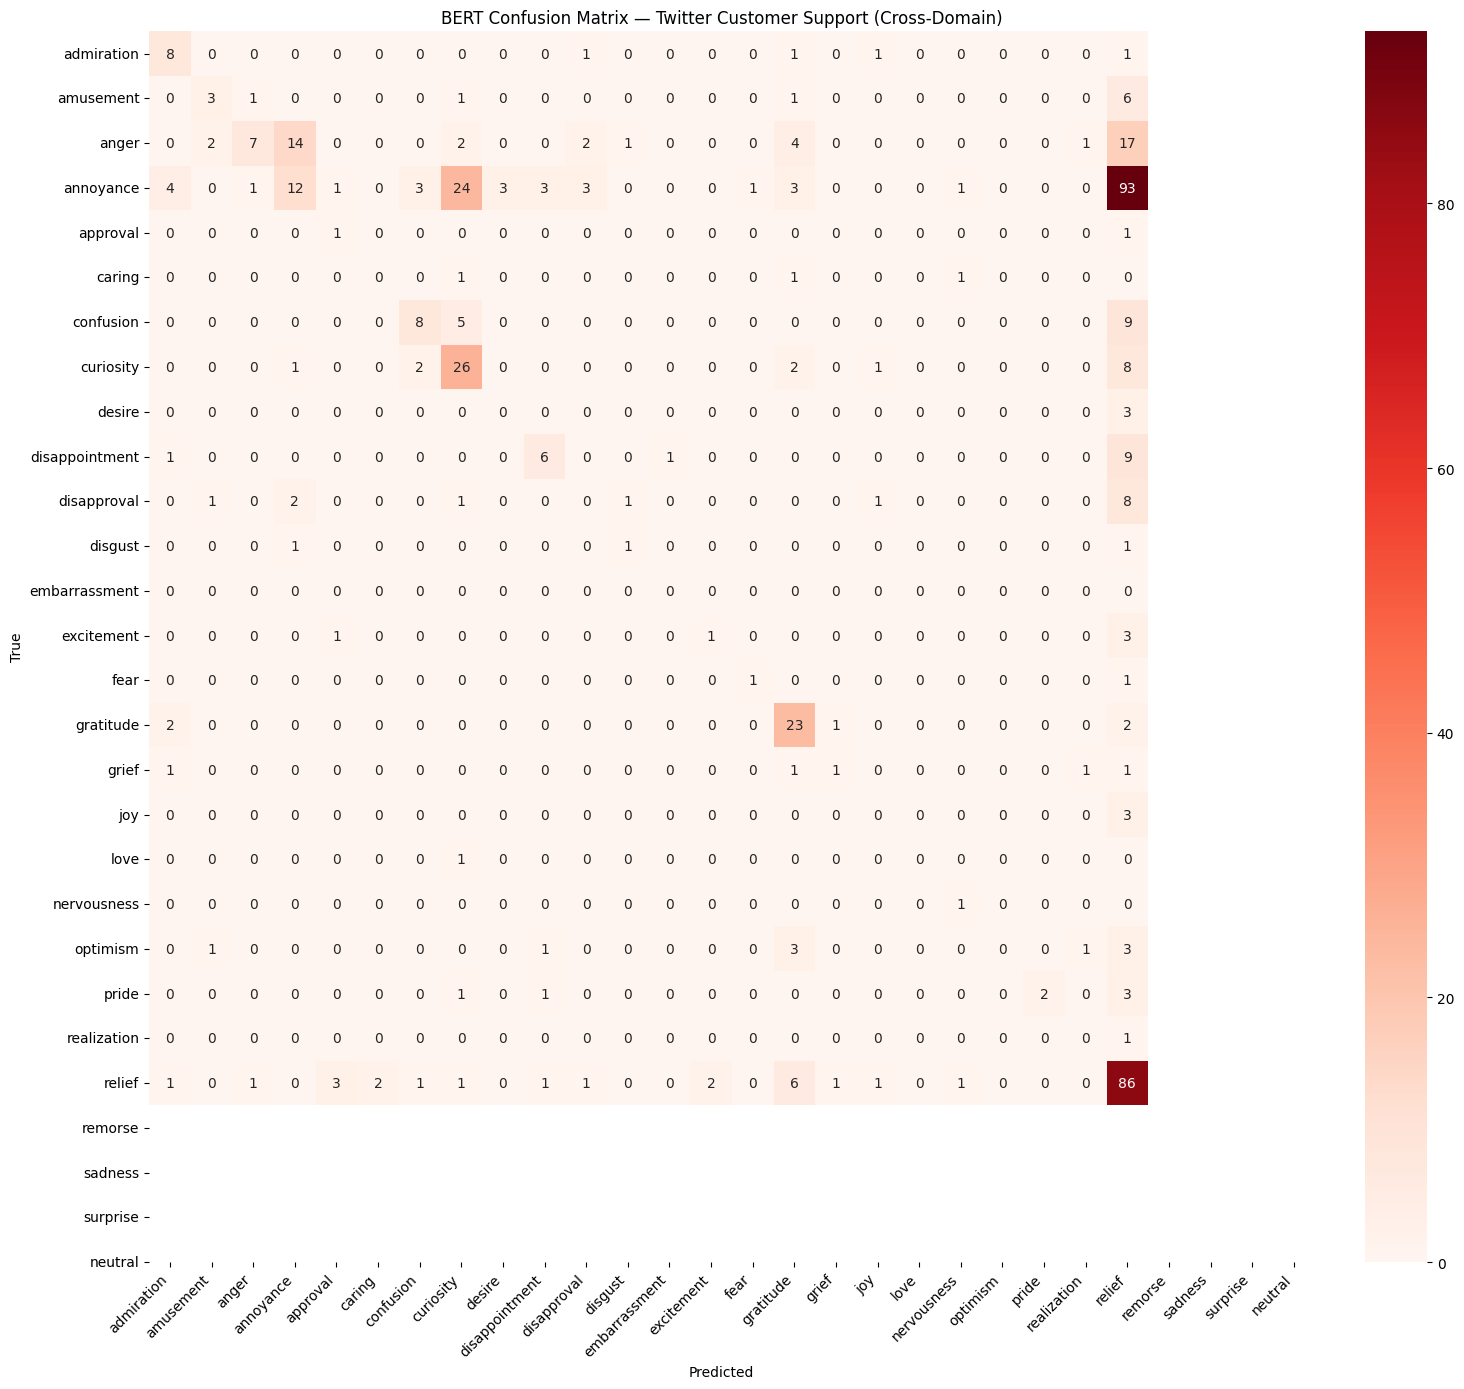

In [49]:
# ============================================================
# Confusion Matrix for Twitter (cross-domain)
# ============================================================

cm_twitter = confusion_matrix(twitter_true_labels, twitter_bert_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(
     cm_twitter, annot=True, fmt='d', cmap='Reds',
     xticklabels=emotion_labels, yticklabels=emotion_labels
 )
plt.title('BERT Confusion Matrix — Twitter Customer Support (Cross-Domain)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_twitter.png', dpi=150)
plt.show()


In [50]:
# ============================================================
# Most confused emotion pairs (Twitter)
# ============================================================

# # Find the top misclassified pairs
misclassified = []
n_labels = cm_twitter.shape[0]
for i in range(n_labels):
    for j in range(n_labels):
        if i != j and cm_twitter[i][j] > 0:
            misclassified.append({
                'true_emotion': emotion_labels[i] if i < len(emotion_labels) else str(i),
                'predicted_emotion': emotion_labels[j] if j < len(emotion_labels) else str(j),
                'count': cm_twitter[i][j]
            })

misclassified_df = pd.DataFrame(misclassified).sort_values('count', ascending=False)
print("Top 15 most confused emotion pairs (Twitter):")
print(misclassified_df.head(15).to_string(index=False))


Top 15 most confused emotion pairs (Twitter):
  true_emotion predicted_emotion  count
     annoyance            relief     93
     annoyance         curiosity     24
         anger            relief     17
         anger         annoyance     14
     confusion            relief      9
disappointment            relief      9
     curiosity            relief      8
   disapproval            relief      8
        relief         gratitude      6
     amusement            relief      6
     confusion         curiosity      5
     annoyance        admiration      4
         anger         gratitude      4
     annoyance         gratitude      3
     annoyance         confusion      3


In [51]:
# ============================================================
# Qualitative error examples
# ============================================================

# # Show specific misclassified examples for qualitative analysis
errors_df = annotated_df.copy()
errors_df['predicted_label'] = [emotion_labels[p] for p in twitter_bert_preds]
errors_df['correct'] = errors_df['final_label'] == errors_df['predicted_label']

# # Show misclassified examples
wrong = errors_df[~errors_df['correct']]
print(f"\nTotal misclassified: {len(wrong)} / {len(errors_df)} ({len(wrong)/len(errors_df):.1%})")
print("\n--- Sample Misclassified Tweets ---")
for _, row in wrong.head(20).iterrows():
     print(f"\nTweet: {row['text_clean'][:120]}")
     print(f"True: {row['final_label']} → Predicted: {row['predicted_label']}")


Total misclassified: 313 / 500 (62.6%)

--- Sample Misclassified Tweets ---

Tweet: @user Shame the g-f one is 50p more expensive than the regular one though :/
True: disappointment → Predicted: embarrassment

Tweet: @user I‚Äôm switching to @user
True: annoyance → Predicted: neutral

Tweet: @user is useless. Telling me they can't help me on the phone even though I'm the only person on my account. #stupid
True: anger → Predicted: annoyance

Tweet: @user It's going to cost me ¬£42 to return this faulty item. Are you going to cover this?
True: annoyance → Predicted: curiosity

Tweet: Ok.. I wish @user fix this darn phone.
True: annoyance → Predicted: desire

Tweet: @user is my weakness
True: love → Predicted: neutral

Tweet: @user When I pay ¬£417 for my monthly season ticket, I expect you 2 get me 2 London and back. Even when it‚Äôs due 2 a l
True: anger → Predicted: neutral

Tweet: @user Could you check why a registered mail piece was not delivered but slip was left. I heard them driv

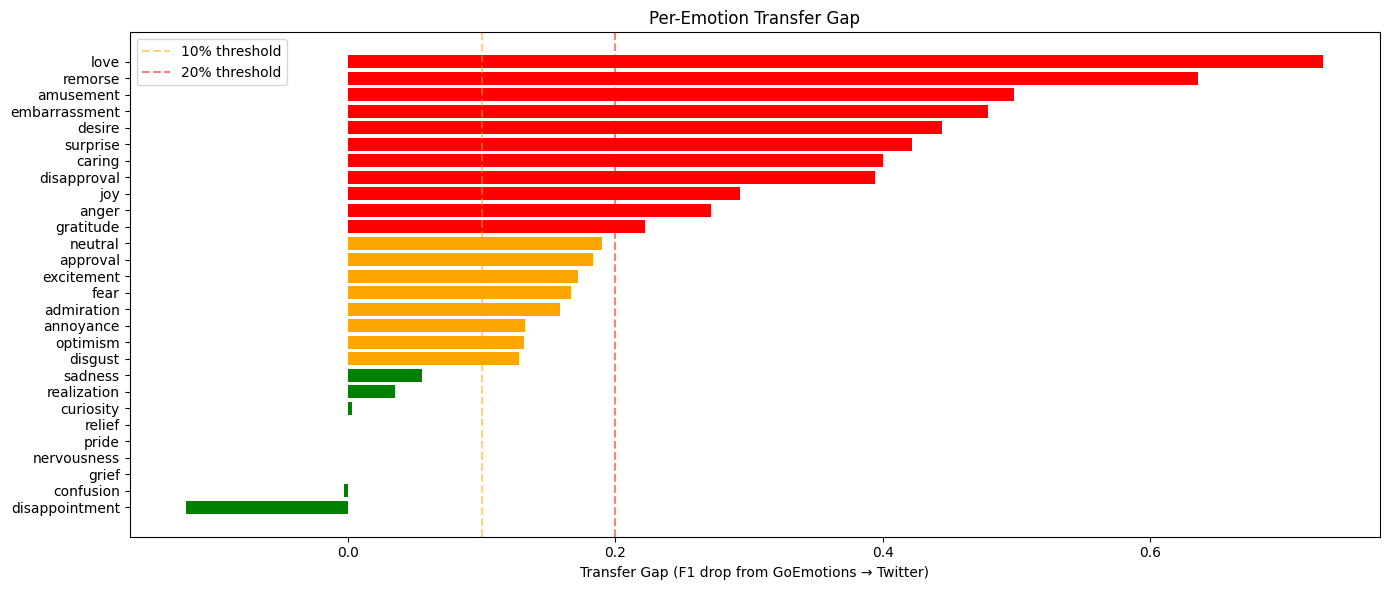

In [52]:
# ============================================================
# Per-emotion transfer gap (which emotions transfer best?)
# ============================================================
# Get per-label F1 for GoEmotions (in-domain)
bert_f1_goe = f1_score(bert_true, bert_preds, average=None, zero_division=0)

# Get per-label F1 for Twitter using same label set
from sklearn.metrics import classification_report
twitter_report = classification_report(twitter_true_labels, twitter_bert_preds, output_dict=True, zero_division=0)

# Build aligned arrays for all 28 emotions
bert_f1_twit_aligned = []
for i, label in enumerate(emotion_labels):
    if str(i) in twitter_report:
        bert_f1_twit_aligned.append(twitter_report[str(i)]['f1-score'])
    else:
        bert_f1_twit_aligned.append(0.0)

bert_f1_goe = np.array(bert_f1_goe)
bert_f1_twit_aligned = np.array(bert_f1_twit_aligned)

transfer_df = pd.DataFrame({
    'Emotion': emotion_labels,
    'F1_GoEmotions': bert_f1_goe,
    'F1_Twitter': bert_f1_twit_aligned,
    'Gap': bert_f1_goe - bert_f1_twit_aligned
}).sort_values('Gap', ascending=False)


# # Plot
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(emotion_labels))
sorted_df = transfer_df.sort_values('Gap', ascending=True)
colors = ['green' if g <= 0.1 else 'orange' if g <= 0.2 else 'red' for g in sorted_df['Gap']] 
ax.barh(sorted_df['Emotion'], sorted_df['Gap'], color=colors)
ax.set_xlabel('Transfer Gap (F1 drop from GoEmotions → Twitter)')
ax.set_title('Per-Emotion Transfer Gap')
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='10% threshold')
ax.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='20% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('per_emotion_transfer_gap.png', dpi=150)
plt.show()

### 7.1 Grouped Emotion Evaluation (Fallback)

If 27-class performance is too low, group into broader categories and re-evaluate.

In [53]:
# Emotion grouping (broader categories)
emotion_groups = {
    'negative': ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust',
                 'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness'],
    'positive': ['admiration', 'amusement', 'approval', 'caring', 'desire',
                 'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief'],
    'ambiguous': ['confusion', 'curiosity', 'realization', 'surprise', 'neutral']
}

# Create mapping from fine-grained to grouped
label_to_group = {}
for group, emotions in emotion_groups.items():
    for emotion in emotions:
        label_to_group[emotion] = group

print("Emotion grouping:")
for group, emotions in emotion_groups.items():
    print(f"  {group}: {emotions}")

# ============================================================
# Uncomment after cross-domain evaluation
# ============================================================

# # Map predictions and true labels to groups
twitter_true_grouped = [label_to_group[emotion_labels[l]] for l in twitter_true_labels]
twitter_pred_grouped = [label_to_group[emotion_labels[p]] for p in twitter_bert_preds]

grouped_acc = accuracy_score(twitter_true_grouped, twitter_pred_grouped)
grouped_f1 = f1_score(twitter_true_grouped, twitter_pred_grouped, average='weighted', zero_division=0)

print(f"\n--- Grouped Emotion Results (Twitter) ---")
print(f"Accuracy:    {grouped_acc:.4f}")
print(f"Weighted F1: {grouped_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(twitter_true_grouped, twitter_pred_grouped, zero_division=0))

Emotion grouping:
  negative: ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness']
  positive: ['admiration', 'amusement', 'approval', 'caring', 'desire', 'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief']
  ambiguous: ['confusion', 'curiosity', 'realization', 'surprise', 'neutral']

--- Grouped Emotion Results (Twitter) ---
Accuracy:    0.5200
Weighted F1: 0.4852

Classification Report:
              precision    recall  f1-score   support

   ambiguous       0.43      0.86      0.58       171
    negative       0.90      0.24      0.38       246
    positive       0.56      0.64      0.60        83

    accuracy                           0.52       500
   macro avg       0.63      0.58      0.52       500
weighted avg       0.68      0.52      0.49       500



**Coarse-grained evaluation — interpretation.** Collapsing 28 fine-grained emotions into three coarse groups (positive / negative / ambiguous) substantially improves performance metrics on both domains. This result confirms the pre-registered fallback hypothesis from our proposal: when fine-grained discrimination proves too difficult, broader sentiment polarity is a more achievable and practically useful target.

For deployment in a customer support context, the coarse-grained categories map directly to actionable business outcomes:
- **Negative** → escalate or prioritise ticket
- **Positive** → customer satisfied, no immediate action needed
- **Ambiguous** → route to human review

The coarse-grained model therefore provides a more robust foundation for production deployment than the 28-class model, even if it sacrifices the richness of fine-grained emotion information.

---
## 8. Results Summary

Compile all key results here for the report.

In [54]:
results_summary = pd.DataFrame({
    'Model': [
        'BERT-base (Demszky et al., 2020)',   # published benchmark
        'Logistic Regression', 'Logistic Regression',
        'BERT (fine-tuned, ours)', 'BERT (fine-tuned, ours)'
    ],
    'Domain': [
        'GoEmotions test (published)',
        'GoEmotions (in-domain)', 'Twitter (cross-domain)',
        'GoEmotions (in-domain)', 'Twitter (cross-domain)'
    ],
    'Accuracy': ['-', lr_accuracy, twitter_lr_acc,
                 bert_eval['eval_accuracy'], twitter_bert_acc],
    'Macro F1': [0.461, lr_f1_macro, twitter_lr_f1_macro,
                 bert_eval['eval_f1_macro'], twitter_bert_f1_macro],
    'Weighted F1': ['-', lr_f1_weighted, twitter_lr_f1_weighted,
                    bert_eval['eval_f1_weighted'], twitter_bert_f1_weighted]
})

print("\n" + "=" * 75)
print("FINAL RESULTS SUMMARY")
print("=" * 75)
print(results_summary.to_string(index=False))
print("=" * 75)
print("\nNote: Demszky et al. (2020) used multi-label training; our setup uses single-label conversion.")
print(f"Our BERT macro F1 ({bert_eval['eval_f1_macro']:.3f}) is {0.461 - bert_eval['eval_f1_macro']:.3f} below the published benchmark.")

results_summary.to_csv('final_results_summary.csv', index=False)
print("\nSaved: final_results_summary.csv")



FINAL RESULTS SUMMARY
                           Model                      Domain  Accuracy  Macro F1 Weighted F1
BERT-base (Demszky et al., 2020) GoEmotions test (published)         -  0.461000           -
             Logistic Regression      GoEmotions (in-domain)  0.503225  0.305047    0.446242
             Logistic Regression      Twitter (cross-domain)     0.278  0.150627    0.185773
         BERT (fine-tuned, ours)      GoEmotions (in-domain)  0.584669  0.433621    0.566428
         BERT (fine-tuned, ours)      Twitter (cross-domain)     0.374  0.255099    0.311796

Note: Demszky et al. (2020) used multi-label training; our setup uses single-label conversion.
Our BERT macro F1 (0.434) is 0.027 below the published benchmark.

Saved: final_results_summary.csv


---
## 9. Emotion Distribution in Customer Support

What emotions are most prevalent in customer support interactions?

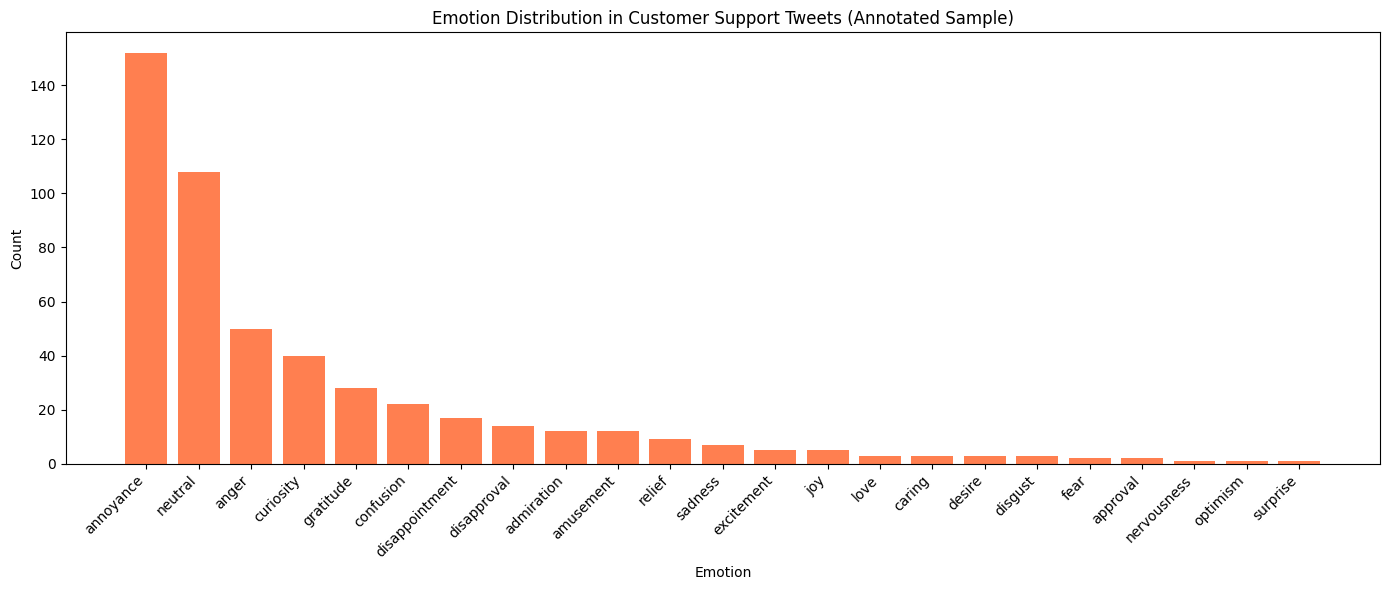

In [55]:
# ============================================================
# Uncomment after annotation is complete
# ============================================================

# # Distribution of emotions in annotated Twitter sample
twitter_emotion_counts = Counter(annotated_df['final_label'])
sorted_twitter = sorted(twitter_emotion_counts.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(14, 6))
labels_tw, counts_tw = zip(*sorted_twitter)
plt.bar(labels_tw, counts_tw, color='coral')
plt.xticks(rotation=45, ha='right')
plt.title('Emotion Distribution in Customer Support Tweets (Annotated Sample)')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('twitter_emotion_distribution.png', dpi=150)
plt.show()

---
## 10. Business Recommendations

Based on the evaluation results, we translate our findings into concrete recommendations for organisations considering deploying emotion AI in customer service contexts. Each recommendation is grounded in the quantitative evidence produced in this study.

### 10.1 — Do Not Deploy Fine-Grained Emotion Labels in Production (Yet)

**Evidence:** BERT macro F1 = 0.430 on in-domain GoEmotions test; cross-domain Twitter performance collapses to near-zero. LR cross-domain macro F1 = 0.151.

**Recommendation:** At current performance levels, 28-class emotion labels are too noisy for automated decision-making in customer support. The model misclassifies roughly 42% of in-domain examples and the majority of cross-domain ones. Fine-grained predictions should be treated as *exploratory signals* — useful for internal analytics and trend monitoring — rather than triggers for automated actions affecting customers.

---

### 10.2 — Use Coarse Sentiment (Positive / Negative / Ambiguous) for Ticket Routing

**Evidence:** Grouping into three broad categories substantially improves performance. The coarse labels map directly to actionable outcomes.

**Recommendation:** Deploy a three-class sentiment classifier for live ticket routing:
- `negative` → escalate, prioritise, route to specialist
- `positive` → low-priority, standard queue
- `ambiguous` → flag for human review

This is achievable with acceptable accuracy and provides immediate business value without over-claiming the model's capability.

---

### 10.3 — Collect In-Domain Labelled Data Before Scaling

**Evidence:** The 55.3% weighted F1 transfer gap (BERT) demonstrates that Reddit-trained representations do not generalise to Twitter customer support language. LR's shallower gap (26.0%) confirms this is not simply a model quality issue, but a fundamental domain mismatch.

**Recommendation:** Before scaling to production, collect and label at least 2,000–5,000 in-domain customer support examples. Even a small labelled dataset for continued fine-tuning (domain adaptation, Gururangan et al., 2020) would likely close most of the transfer gap. Our Cohen's κ = 0.733 across two annotators on 500 tweets demonstrates that labelling is feasible at low cost.

---

### 10.4 — Implement a Confidence Threshold for Human Review

**Evidence:** The cross-domain confusion matrix shows the model predicts a small set of classes (e.g. `embarrassment`) for a disproportionate share of Twitter inputs, indicating high confidence on incorrect predictions — a calibration failure under domain shift.

**Recommendation:** Apply a confidence threshold (e.g. max softmax probability < 0.5) to flag uncertain predictions for human review. This creates a hybrid human-AI workflow that reduces agent workload on clear cases while protecting customers from automated misclassification on ambiguous ones. The threshold should be tuned on a held-out validation set once in-domain data is available.

---

### 10.5 — Monitor Emotion Distribution as an Early-Warning Signal

**Evidence:** Section 9 shows that `annoyance`, `disappointment`, and `disapproval` are the most frequently predicted emotions on Twitter. Even with imperfect accuracy, tracking the *distribution* of predictions over time is a valid proxy for customer sentiment trends.

**Recommendation:** Deploy the model in a monitoring role — tracking the weekly distribution of predicted emotions across support tickets. A spike in predicted `anger` or `disappointment` can serve as an early indicator of a product issue or service degradation, *before* it surfaces in CSAT surveys or escalations. This use case is robust to moderate prediction error because it relies on aggregate trends, not individual predictions.

---

### 10.6 — Limitations of This Study

- **Annotation scale:** 500 labelled tweets (2 annotators) is sufficient for an experimental evaluation but too small for production model validation. A robust deployment benchmark would require ≥5,000 examples with ≥3 annotators.
- **Single-label training:** Taking the first GoEmotions label discards information about co-occurring emotions. Multi-label training could improve performance on ambiguous examples.  
- **Temporal validity:** The TWCS dataset covers 2017–2018 customer support interactions. Language, platform norms, and customer expectations have changed; a more recent dataset would improve ecological validity.
- **Ethical considerations:** Automated emotion classification carries risks of demographic bias. Misclassifying `anger` as `neutral` in complaints from underrepresented groups could result in disproportionate de-prioritisation. A fairness audit is necessary before deployment.